<a href="https://colab.research.google.com/github/viktoruebelhart/pos_facens/blob/main/RegLOGS_AULA2ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# variável de entrada
X = np.array([
    18,20,22,24,26,28,30,32,34,36,
    38,40,42,44,46,48,50,52,54,56
]).reshape(-1,1)

# variável de saída
y = np.array([
    0,0,0,0,0,0,0,0,
    1,0,
    1,1,1,1,1,1,1,1,1,1
])


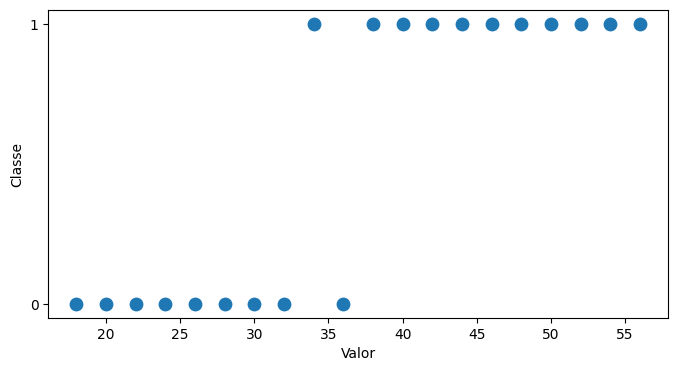

In [2]:
plt.figure(figsize=(8,4))

plt.scatter(X, y, s=80)

plt.xlabel("Valor")
plt.ylabel("Classe")
plt.yticks([0,1])

plt.show()

In [3]:
from sklearn.linear_model import LogisticRegression

modelo = LogisticRegression()

modelo.fit(X, y)

LogisticRegression()

In [4]:
predicoes = modelo.predict(X)

predicoes

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [5]:
np.set_printoptions(suppress=True, precision=8)
probs = modelo.predict_proba(X)

probs

array([[0.99994267, 0.00005733],
       [0.99981915, 0.00018085],
       [0.99942962, 0.00057038],
       [0.99820258, 0.00179742],
       [0.99435084, 0.00564916],
       [0.98239064, 0.01760936],
       [0.94647191, 0.05352809],
       [0.84858051, 0.15141949],
       [0.63979789, 0.36020211],
       [0.36019064, 0.63980936],
       [0.1514131 , 0.8485869 ],
       [0.05352557, 0.94647443],
       [0.0176085 , 0.9823915 ],
       [0.00564888, 0.99435112],
       [0.00179733, 0.99820267],
       [0.00057036, 0.99942964],
       [0.00018084, 0.99981916],
       [0.00005732, 0.99994268],
       [0.00001817, 0.99998183],
       [0.00000576, 0.99999424]])

In [6]:
#somente para a classe 1
prob_classe1 = modelo.predict_proba(X)[:,1]

prob_classe1

array([0.00005733, 0.00018085, 0.00057038, 0.00179742, 0.00564916,
       0.01760936, 0.05352809, 0.15141949, 0.36020211, 0.63980936,
       0.8485869 , 0.94647443, 0.9823915 , 0.99435112, 0.99820267,
       0.99942964, 0.99981916, 0.99994268, 0.99998183, 0.99999424])

In [7]:
X_plot = np.linspace(15,60,300).reshape(-1,1)

prob_plot = modelo.predict_proba(X_plot)[:,1]

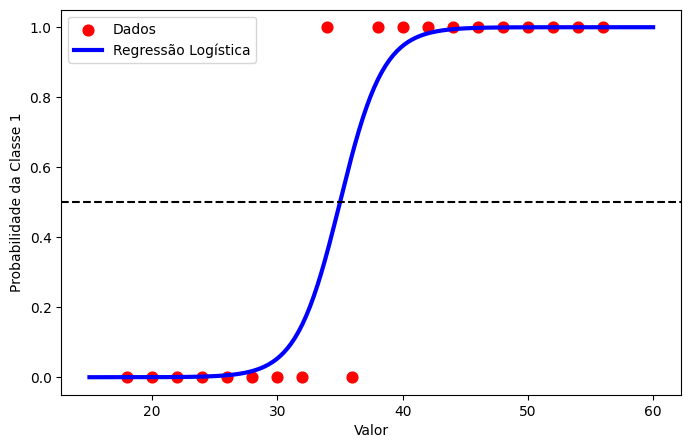

In [8]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color="red", s=60, label="Dados")

plt.plot(
    X_plot,
    prob_plot,
    color="blue",
    linewidth=3,
    label="Regressão Logística"
)

plt.axhline(0.5,
            color="black",
            linestyle="--")

plt.xlabel("Valor")
plt.ylabel("Probabilidade da Classe 1")

plt.legend()

plt.show()

In [9]:
coef = modelo.coef_[0][0]
intercepto = modelo.intercept_[0]

fronteira = -intercepto / coef

print(f"Fronteira de decisão: {fronteira:.2f}")

Fronteira de decisão: 35.00


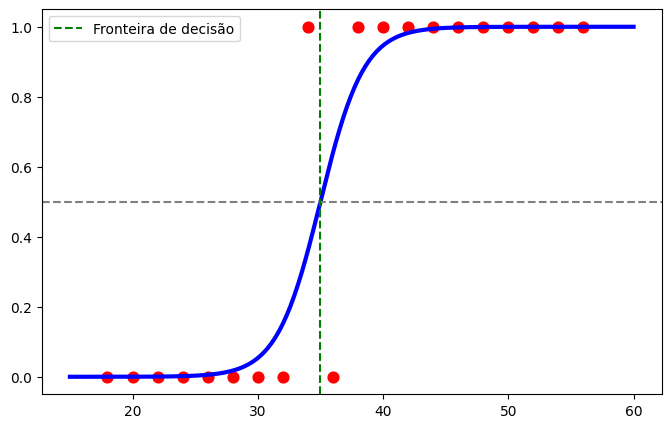

In [10]:
plt.figure(figsize=(8,5))

plt.scatter(X, y, color="red", s=60)

plt.plot(X_plot,
         prob_plot,
         color="blue",
         linewidth=3)

plt.axhline(0.5,
            color="gray",
            linestyle="--")

plt.axvline(fronteira,
            color="green",
            linestyle="--",
            label="Fronteira de decisão")

plt.legend()

plt.show()

In [11]:
novos = np.array([[27],
                  [34],
                  [35],
                  [45]])

resultado = pd.DataFrame({
    "Valor": novos.flatten(),
    "Probabilidade Classe 1":
        modelo.predict_proba(novos)[:,1],
    "Classe Prevista":
        modelo.predict(novos)
})

resultado

,Valor,Probabilidade Classe 1,Classe Prevista
0,27,0.009991,0
1,34,0.360202,0
2,35,0.500006,1
3,45,0.996812,1
